# Fuel Duty Freeze and 5p Cut Extension Analysis

This notebook analyzes the effect of extending the fuel duty freeze and maintaining the 5p cut beyond March 2026.

## Summary of Reform

**Baseline Scenario (Pre-Budget 2025):**
- Fuel duty rate: £0.5295 per litre (52.95p) until March 2026
- From March 2026: Rate increases to £0.5795 per litre (57.95p) - reverting the 5p cut

**Reformed Scenario (Budget 2025 Announcement):**
- Fuel duty rate: £0.5295 per litre (52.95p) maintained through 2027
- The 5p cut introduced by Rishi Sunak in March 2022 is kept in place
- This represents the 15th consecutive year of fuel duty freeze

**Additional Policy:**
- Introduction of "Pumpwatch" scheme requiring forecourts to publish prices
- Expected savings: ~£40 per family annually from price transparency

**Cost to Treasury:**
- Estimated at £3 billion per year (2025/26 OBR estimate)

In [ ]:
# Install local version of policyengine-uk for testing
# !pip uninstall -y policyengine-uk
# !pip install -e /Users/janansadeqian/policyengine-uk --config-settings editable_mode=compat

In [1]:
from policyengine_uk import Microsimulation, Scenario
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

/Users/janansadeqian/anaconda3/envs/python313/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from policyengine_uk.data import UKSingleYearDataset

# Load local dataset
dataset = UKSingleYearDataset(
    file_path="/Users/janansadeqian/policyengine-uk-data/policyengine_uk_data/storage/enhanced_frs_2023_24.h5"
)

# Baseline: Fuel duty reverts to £0.5795 in March 2026 (5p cut expires)
# This is already coded in the current parameters
baseline = Microsimulation(dataset=dataset)

# Reform: Extend the 5p cut - keep fuel duty at £0.5295 through 2027
reformed_scenario = Scenario(
    parameter_changes={
        "gov.hmrc.fuel_duty.petrol_and_diesel": {
            "2026-03-22": 0.5295,  # Keep the reduced rate instead of reverting to 0.5795
            "2027-04-01": 0.5295,  # Extend through 2027
        }
    }
)

reformed = Microsimulation(dataset=dataset, scenario=reformed_scenario)

print("Microsimulations created successfully")
print("\nBaseline: 5p fuel duty cut expires in March 2026 (rate increases to 57.95p)")
print("Reformed: 5p cut maintained at 52.95p through 2027")

Microsimulations created successfully

Baseline: 5p fuel duty cut expires in March 2026 (rate increases to 57.95p)
Reformed: 5p cut maintained at 52.95p through 2027


## Budgetary Impact Analysis

Calculate the cost to the government of maintaining the fuel duty freeze and 5p cut.

In [3]:
# Calculate government balance impact for multiple years
years = [2026, 2027, 2028, 2029]

print("=== Budgetary Impact of Fuel Duty Freeze (Maintaining 5p Cut) ===")
print("\nNote: Negative values = cost to government (revenue foregone)\n")

total_impact = 0
for year in years:
    baseline_balance = baseline.calculate("gov_balance", period=year)
    reformed_balance = reformed.calculate("gov_balance", period=year)
    difference_balance = reformed_balance - baseline_balance
    year_impact = difference_balance.sum() / 1e9
    total_impact += year_impact
    
    print(f"{year}: £{year_impact:,.2f} bn")

print(f"\nTotal (2026-2029): £{total_impact:,.2f} bn")
print(f"Average per year: £{total_impact/len(years):,.2f} bn")

print("\n--- Interpretation ---")
if total_impact < 0:
    print(f"The fuel duty freeze costs the government £{abs(total_impact):,.2f} bn over 4 years")
    print(f"This represents revenue foregone by not increasing the duty rate.")
else:
    print(f"Note: Positive values would indicate increased government revenue.")

=== Budgetary Impact of Fuel Duty Freeze (Maintaining 5p Cut) ===

Note: Negative values = cost to government (revenue foregone)

2026: £0.00 bn
2027: £-1.53 bn
2028: £-1.30 bn
2029: £-1.37 bn

Total (2026-2029): £-4.20 bn
Average per year: £-1.05 bn

--- Interpretation ---
The fuel duty freeze costs the government £4.20 bn over 4 years
This represents revenue foregone by not increasing the duty rate.


## Household Impact Analysis

Analyze how many households benefit from the fuel duty freeze and by how much.

In [5]:
# Calculate total fuel duty paid by all households
baseline_fuel_duty = baseline.calculate("fuel_duty", 2027)
reformed_fuel_duty = reformed.calculate("fuel_duty", 2027)

# Total fuel duty revenue
baseline_total = baseline_fuel_duty.sum() / 1e9
reformed_total = reformed_fuel_duty.sum() / 1e9
difference = reformed_total - baseline_total

print("=== Total Fuel Duty Revenue (2027) ===")
print(f"\nBaseline (with 5p cut expiring): £{baseline_total:,.2f} bn")
print(f"Reformed (5p cut maintained): £{reformed_total:,.2f} bn")
print(f"\nDifference: £{difference:,.2f} bn")
print(f"Percentage change: {100 * difference / baseline_total:,.2f}%")

=== Total Fuel Duty Revenue (2027) ===

Baseline (with 5p cut expiring): £42.42 bn
Reformed (5p cut maintained): £40.89 bn

Difference: £-1.53 bn
Percentage change: -3.61%


In [6]:
# Load household-level data
vars_to_load = [
    'person_id',
    'household_id',
    'petrol_litres',
    'diesel_litres',
    'fuel_duty',
    'household_net_income',
    'person_weight',
    'household_weight',
]

baseline_data = {}
reformed_data = {}

for var in vars_to_load:
    baseline_data[var] = baseline.calculate(var, 2027, map_to="person").values
    reformed_data[var] = reformed.calculate(var, 2027, map_to="person").values

baseline_df = pd.DataFrame(baseline_data)
reformed_df = pd.DataFrame(reformed_data)

# Calculate fuel consumption and savings
baseline_df['total_fuel_litres'] = baseline_df['petrol_litres'] + baseline_df['diesel_litres']
baseline_df['reformed_fuel_duty'] = reformed_df['fuel_duty']
baseline_df['fuel_duty_savings'] = baseline_df['fuel_duty'] - baseline_df['reformed_fuel_duty']
baseline_df['reformed_net_income'] = reformed_df['household_net_income']
baseline_df['net_income_change'] = baseline_df['reformed_net_income'] - baseline_df['household_net_income']

print(f"Loaded {len(baseline_df)} person records")

Loaded 115612 person records


In [7]:
# Analyze households with fuel consumption
total_population = baseline_df['person_weight'].sum()
fuel_users = baseline_df[baseline_df['total_fuel_litres'] > 0]
fuel_users_count = fuel_users['person_weight'].sum()

# Average fuel consumption
avg_fuel_all = (baseline_df['total_fuel_litres'] * baseline_df['person_weight']).sum() / total_population
avg_fuel_users = (fuel_users['total_fuel_litres'] * fuel_users['person_weight']).sum() / fuel_users_count

# Average fuel duty paid
avg_duty_all_baseline = (baseline_df['fuel_duty'] * baseline_df['person_weight']).sum() / total_population
avg_duty_all_reformed = (baseline_df['reformed_fuel_duty'] * baseline_df['person_weight']).sum() / total_population
avg_duty_users_baseline = (fuel_users['fuel_duty'] * fuel_users['person_weight']).sum() / fuel_users_count
avg_duty_users_reformed = (fuel_users['reformed_fuel_duty'] * fuel_users['person_weight']).sum() / fuel_users_count

# Average savings
avg_savings_all = (baseline_df['fuel_duty_savings'] * baseline_df['person_weight']).sum() / total_population
avg_savings_users = (fuel_users['fuel_duty_savings'] * fuel_users['person_weight']).sum() / fuel_users_count

print("=== Fuel Consumption and Duty Statistics ===")
print(f"\nTotal population: {total_population:,.0f}")
print(f"People in fuel-consuming households: {fuel_users_count:,.0f}")
print(f"Percentage of population: {100 * fuel_users_count / total_population:.2f}%")

print(f"\n--- Average Annual Fuel Consumption (litres) ---")
print(f"All population: {avg_fuel_all:,.0f} litres")
print(f"Fuel users only: {avg_fuel_users:,.0f} litres")

print(f"\n--- Average Annual Fuel Duty Paid ---")
print(f"All population (baseline): £{avg_duty_all_baseline:,.2f}")
print(f"All population (reformed): £{avg_duty_all_reformed:,.2f}")
print(f"\nFuel users only (baseline): £{avg_duty_users_baseline:,.2f}")
print(f"Fuel users only (reformed): £{avg_duty_users_reformed:,.2f}")

print(f"\n--- Average Annual Savings from Fuel Duty Freeze ---")
print(f"All population: £{avg_savings_all:,.2f}")
print(f"Fuel users only: £{avg_savings_users:,.2f}")

# Calculate per litre rate difference
rate_difference = 0.5795 - 0.5295  # 5p difference
print(f"\n--- Rate Comparison ---")
print(f"Baseline rate (2027): £0.5795/litre (57.95p)")
print(f"Reformed rate (2027): £0.5295/litre (52.95p)")
print(f"Difference: £{rate_difference:.4f}/litre ({rate_difference*100:.2f}p)")
print(f"\nFor a typical fuel user consuming {avg_fuel_users:,.0f} litres/year:")
print(f"Annual savings = {avg_fuel_users:,.0f} litres × {rate_difference*100:.0f}p = £{avg_savings_users:,.2f}")

=== Fuel Consumption and Duty Statistics ===

Total population: 69,128,336
People in fuel-consuming households: 34,909,816
Percentage of population: 50.50%

--- Average Annual Fuel Consumption (litres) ---
All population: 1,267 litres
Fuel users only: 2,509 litres

--- Average Annual Fuel Duty Paid ---
All population (baseline): £1,512.70
All population (reformed): £1,458.08

Fuel users only (baseline): £2,995.45
Fuel users only (reformed): £2,887.30

--- Average Annual Savings from Fuel Duty Freeze ---
All population: £54.62
Fuel users only: £108.15

--- Rate Comparison ---
Baseline rate (2027): £0.5795/litre (57.95p)
Reformed rate (2027): £0.5295/litre (52.95p)
Difference: £0.0500/litre (5.00p)

For a typical fuel user consuming 2,509 litres/year:
Annual savings = 2,509 litres × 5p = £108.15


## Impact by Income Decile

Analyze how the fuel duty freeze affects households across the income distribution.

In [8]:
# Load income decile data
baseline_df['income_decile'] = baseline.calculate('income_decile', 2027, map_to="person").values

# Filter out negative deciles
decile_df = baseline_df[baseline_df['income_decile'] >= 1].copy()

print(f"Analyzing {len(decile_df)} person records (excluding negative income deciles)")

Analyzing 114674 person records (excluding negative income deciles)


In [9]:
# Calculate statistics by income decile
decile_stats = decile_df.groupby('income_decile').apply(
    lambda g: pd.Series({
        'people': g['person_weight'].sum(),
        'avg_fuel_litres': (g['total_fuel_litres'] * g['person_weight']).sum() / g['person_weight'].sum(),
        'avg_fuel_duty_baseline': (g['fuel_duty'] * g['person_weight']).sum() / g['person_weight'].sum(),
        'avg_fuel_duty_reformed': (g['reformed_fuel_duty'] * g['person_weight']).sum() / g['person_weight'].sum(),
        'avg_savings': (g['fuel_duty_savings'] * g['person_weight']).sum() / g['person_weight'].sum(),
        'avg_household_income': (g['household_net_income'] * g['person_weight']).sum() / g['person_weight'].sum(),
        'pct_fuel_users': 100 * (g[g['total_fuel_litres'] > 0]['person_weight'].sum() / g['person_weight'].sum()),
    }), include_groups=False
).reset_index()

# Calculate savings as percentage of income
decile_stats['savings_pct_of_income'] = 100 * decile_stats['avg_savings'] / decile_stats['avg_household_income']

print("\n=== Impact of Fuel Duty Freeze by Income Decile ===")
print(f"\n{'Decile':<8} {'People':>12} {'% Fuel':>10} {'Avg Fuel':>12} {'Avg Savings':>14} {'Savings as %':>14}")
print(f"{'':8} {'':12} {'Users':>10} {'(litres)':>12} {'(£/year)':>14} {'of Income':>14}")
print("="*80)

for _, row in decile_stats.iterrows():
    decile = int(row['income_decile'])
    people = row['people']
    pct_users = row['pct_fuel_users']
    fuel = row['avg_fuel_litres']
    savings = row['avg_savings']
    savings_pct = row['savings_pct_of_income']
    
    print(f"{decile:<8} {people:>12,.0f} {pct_users:>9.1f}% {fuel:>12,.0f} £{savings:>13,.2f} {savings_pct:>13,.3f}%")

# Print totals
total_people = decile_stats['people'].sum()
total_pct_users = 100 * (decile_df[decile_df['total_fuel_litres'] > 0]['person_weight'].sum() / total_people)
total_fuel = (decile_df['total_fuel_litres'] * decile_df['person_weight']).sum() / total_people
total_savings = (decile_df['fuel_duty_savings'] * decile_df['person_weight']).sum() / total_people
total_income = (decile_df['household_net_income'] * decile_df['person_weight']).sum() / total_people
total_savings_pct = 100 * total_savings / total_income

print("="*80)
print(f"{'TOTAL':<8} {total_people:>12,.0f} {total_pct_users:>9.1f}% {total_fuel:>12,.0f} £{total_savings:>13,.2f} {total_savings_pct:>13,.3f}%")


=== Impact of Fuel Duty Freeze by Income Decile ===

Decile         People     % Fuel     Avg Fuel    Avg Savings   Savings as %
                           Users     (litres)       (£/year)      of Income
1           6,504,726      45.9%          962 £        41.44         0.138%
2           6,906,078      52.1%        1,139 £        49.08         0.121%
3           6,898,492      48.1%          905 £        39.02         0.091%
4           6,935,624      52.6%        1,299 £        56.01         0.116%
5           6,875,634      48.6%        1,066 £        45.93         0.082%
6           6,925,369      51.1%        1,172 £        50.53         0.087%
7           6,936,494      58.2%        1,340 £        57.76         0.095%
8           6,907,224      52.2%        1,519 £        65.46         0.097%
9           6,910,958      44.8%        1,531 £        65.97         0.076%
10          6,921,369      52.9%        1,756 £        75.66         0.049%
TOTAL      68,721,968      50.7%  

## Visualization: Impact by Income Decile

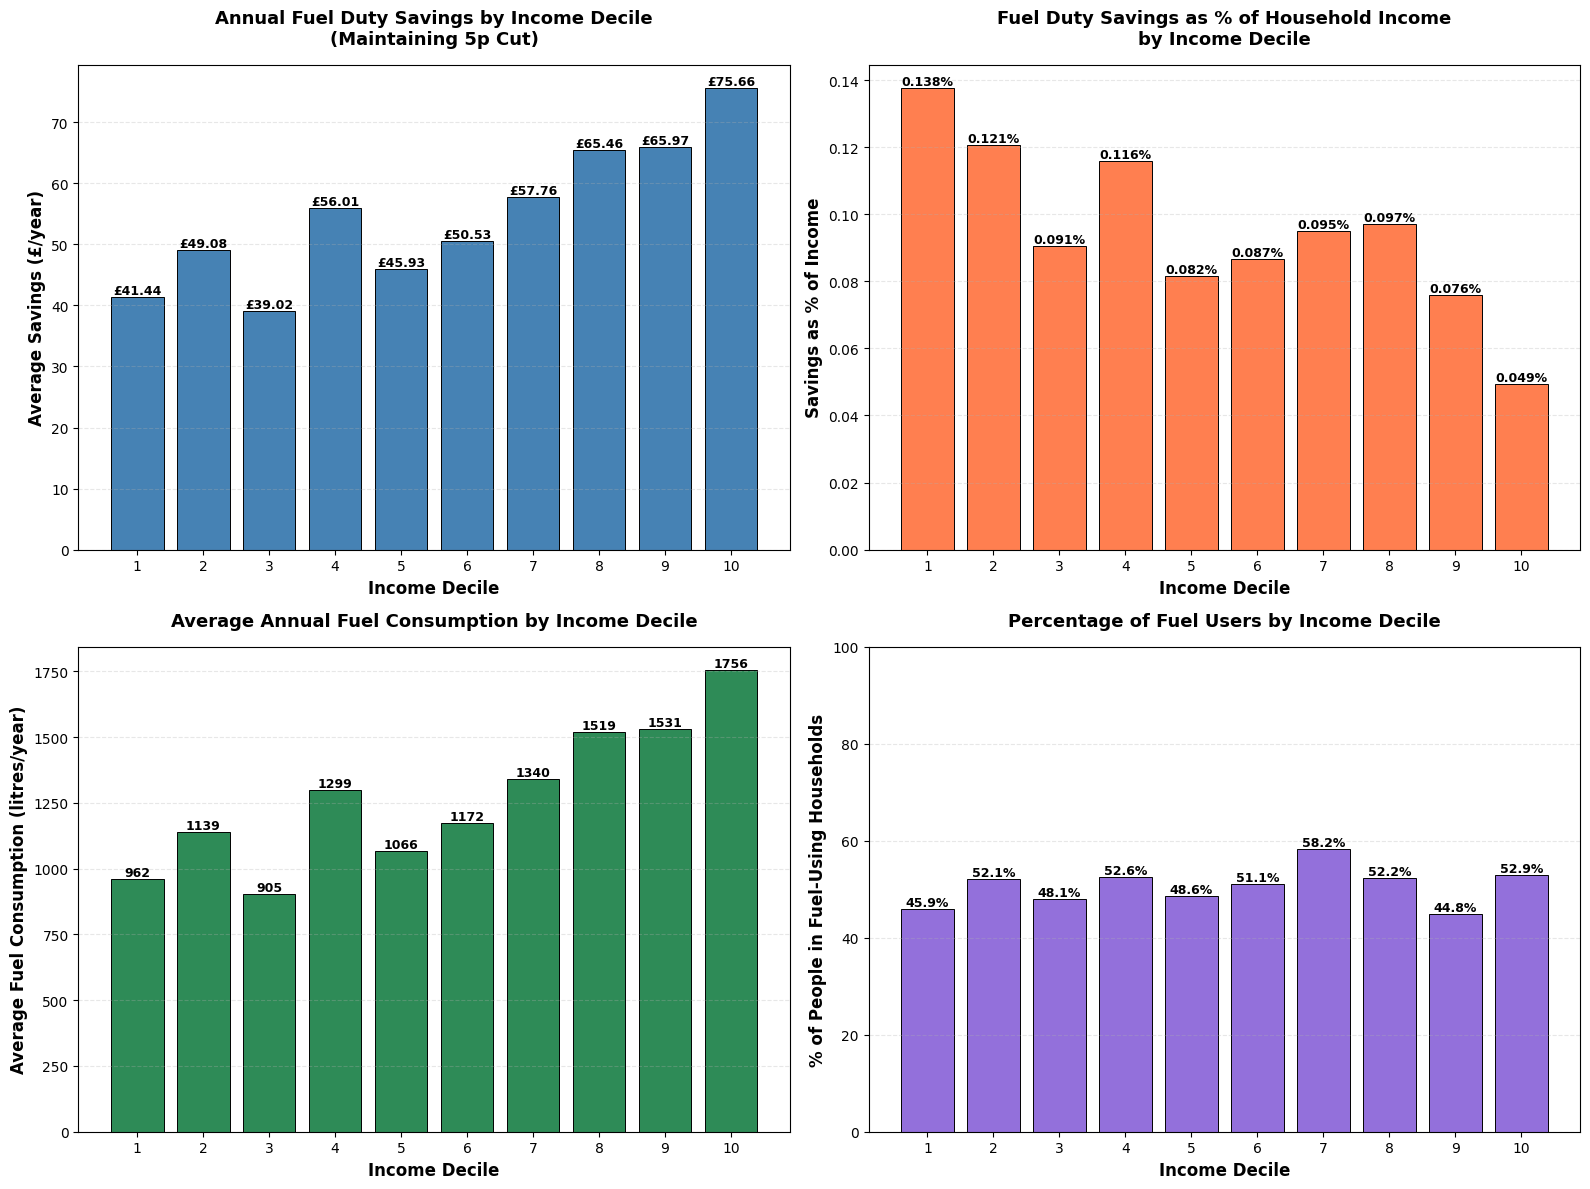

In [10]:
# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Average savings in pounds
ax1 = axes[0, 0]
ax1.bar(decile_stats['income_decile'], 
        decile_stats['avg_savings'],
        color='steelblue',
        edgecolor='black',
        linewidth=0.7)
ax1.set_xlabel('Income Decile', fontsize=12, fontweight='bold')
ax1.set_ylabel('Average Savings (£/year)', fontsize=12, fontweight='bold')
ax1.set_title('Annual Fuel Duty Savings by Income Decile\n(Maintaining 5p Cut)', 
              fontsize=13, fontweight='bold', pad=15)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.set_xticks(range(1, 11))

for _, row in decile_stats.iterrows():
    ax1.text(row['income_decile'], row['avg_savings'], 
             f"£{row['avg_savings']:.2f}",
             ha='center', va='bottom', fontsize=9, fontweight='bold')

# Plot 2: Savings as percentage of income
ax2 = axes[0, 1]
ax2.bar(decile_stats['income_decile'], 
        decile_stats['savings_pct_of_income'],
        color='coral',
        edgecolor='black',
        linewidth=0.7)
ax2.set_xlabel('Income Decile', fontsize=12, fontweight='bold')
ax2.set_ylabel('Savings as % of Income', fontsize=12, fontweight='bold')
ax2.set_title('Fuel Duty Savings as % of Household Income\nby Income Decile', 
              fontsize=13, fontweight='bold', pad=15)
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.set_xticks(range(1, 11))

for _, row in decile_stats.iterrows():
    ax2.text(row['income_decile'], row['savings_pct_of_income'], 
             f"{row['savings_pct_of_income']:.3f}%",
             ha='center', va='bottom', fontsize=9, fontweight='bold')

# Plot 3: Average fuel consumption
ax3 = axes[1, 0]
ax3.bar(decile_stats['income_decile'], 
        decile_stats['avg_fuel_litres'],
        color='seagreen',
        edgecolor='black',
        linewidth=0.7)
ax3.set_xlabel('Income Decile', fontsize=12, fontweight='bold')
ax3.set_ylabel('Average Fuel Consumption (litres/year)', fontsize=12, fontweight='bold')
ax3.set_title('Average Annual Fuel Consumption by Income Decile', 
              fontsize=13, fontweight='bold', pad=15)
ax3.grid(axis='y', alpha=0.3, linestyle='--')
ax3.set_xticks(range(1, 11))

for _, row in decile_stats.iterrows():
    ax3.text(row['income_decile'], row['avg_fuel_litres'], 
             f"{row['avg_fuel_litres']:.0f}",
             ha='center', va='bottom', fontsize=9, fontweight='bold')

# Plot 4: Percentage of fuel users
ax4 = axes[1, 1]
ax4.bar(decile_stats['income_decile'], 
        decile_stats['pct_fuel_users'],
        color='mediumpurple',
        edgecolor='black',
        linewidth=0.7)
ax4.set_xlabel('Income Decile', fontsize=12, fontweight='bold')
ax4.set_ylabel('% of People in Fuel-Using Households', fontsize=12, fontweight='bold')
ax4.set_title('Percentage of Fuel Users by Income Decile', 
              fontsize=13, fontweight='bold', pad=15)
ax4.grid(axis='y', alpha=0.3, linestyle='--')
ax4.set_xticks(range(1, 11))
ax4.set_ylim(0, 100)

for _, row in decile_stats.iterrows():
    ax4.text(row['income_decile'], row['pct_fuel_users'], 
             f"{row['pct_fuel_users']:.1f}%",
             ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## Key Findings Summary

In [11]:
print("=== KEY FINDINGS: FUEL DUTY FREEZE AND 5P CUT EXTENSION ===")
print("\n1. BUDGETARY IMPACT")
print(f"   - Cost to government: ~£{abs(total_impact/len(years)):,.2f} bn per year")
print(f"   - Total over 4 years: £{abs(total_impact):,.2f} bn")

print("\n2. HOUSEHOLD IMPACT")
print(f"   - People in fuel-consuming households: {fuel_users_count/1e6:,.1f} million ({100 * fuel_users_count / total_population:.1f}%)")
print(f"   - Average annual savings (fuel users): £{avg_savings_users:,.2f}")
print(f"   - Average annual savings (all population): £{avg_savings_all:,.2f}")

print("\n3. DISTRIBUTIONAL IMPACT")
# Find decile with highest absolute savings
max_savings_decile = decile_stats.loc[decile_stats['avg_savings'].idxmax()]
min_savings_decile = decile_stats.loc[decile_stats['avg_savings'].idxmin()]
print(f"   - Highest absolute savings: Decile {int(max_savings_decile['income_decile'])} (£{max_savings_decile['avg_savings']:.2f}/year)")
print(f"   - Lowest absolute savings: Decile {int(min_savings_decile['income_decile'])} (£{min_savings_decile['avg_savings']:.2f}/year)")

# Find decile with highest savings as % of income
max_pct_decile = decile_stats.loc[decile_stats['savings_pct_of_income'].idxmax()]
print(f"   - Highest relative impact: Decile {int(max_pct_decile['income_decile'])} ({max_pct_decile['savings_pct_of_income']:.3f}% of income)")

print("\n4. POLICY CONTEXT")
print("   - This represents the 15th consecutive year of fuel duty freeze")
print("   - The 5p cut was originally introduced in March 2022 by Rishi Sunak")
print("   - Without this freeze, fuel duty would increase by 5p per litre")
print("   - Additional 'Pumpwatch' scheme expected to save families ~£40/year")

print("\n5. POLITICAL SIGNIFICANCE")
print("   - Described as a 'rare Budget win' for hard-pressed Britons")
print("   - Helps demonstrate government commitment to cost of living support")
print("   - Prevents pump prices from reaching near-record highs")

=== KEY FINDINGS: FUEL DUTY FREEZE AND 5P CUT EXTENSION ===

1. BUDGETARY IMPACT
   - Cost to government: ~£1.05 bn per year
   - Total over 4 years: £4.20 bn

2. HOUSEHOLD IMPACT
   - People in fuel-consuming households: 34.9 million (50.5%)
   - Average annual savings (fuel users): £108.15
   - Average annual savings (all population): £54.62

3. DISTRIBUTIONAL IMPACT
   - Highest absolute savings: Decile 10 (£75.66/year)
   - Lowest absolute savings: Decile 3 (£39.02/year)
   - Highest relative impact: Decile 1 (0.138% of income)

4. POLICY CONTEXT
   - This represents the 15th consecutive year of fuel duty freeze
   - The 5p cut was originally introduced in March 2022 by Rishi Sunak
   - Without this freeze, fuel duty would increase by 5p per litre
   - Additional 'Pumpwatch' scheme expected to save families ~£40/year

5. POLITICAL SIGNIFICANCE
   - Described as a 'rare Budget win' for hard-pressed Britons
   - Helps demonstrate government commitment to cost of living support
   - P